# Kelsey Trained one model, Let me try also

In [31]:

## Straight up deeplabcut version

# Ref: https://deeplabcut.github.io/DeepLabCut/examples/COLAB/COLAB_YOURDATA_TrainNetwork_VideoAnalysis.html

# open 'Anaconda Navigator' app as an administrator (right click)
# Launch 'CMD.exe Prompt' and type in the commands below

# Launch your conda environment:


#import the package
import deeplabcut

import xrommtools

import os
import pandas as pd
import numpy as np
import cv2
import random
from deeplabcut.pose_estimation_tensorflow.predict_videos import analyze_videos 
import matplotlib.pyplot as plt


# Trying to train

In [ ]:


# RUN THIS SECTION ONLY ONCE, when you first create the projects. 
# If a symbolic link error occurs, make sure you've run Anaconda Nafrovigator "as Administrator"

task='Canari' # Enter the name of your experiment Task
experimenter='Tyler' # Enter the name of the experimenter
video=['..//Endive/trainingdata/Endive20251606Trial32/EndiveF42_20251606_Cam1_short.avi'] # IMPORTANT: This video is a 'dummy' video. Just point the function to something.
working_directory = '..//Endive/TestData/Canari_Cam1_Training' # where the project will be created; use forward slashes on Windows
path_config_file_cam1=deeplabcut.create_new_project(task,experimenter,video,working_directory,copy_videos=False)

# repeat for second camera
video=['..//Endive/trainingdata/Endive20251606Trial32/EndiveF42_20251606_Cam2_short.avi'] 
working_directory = '..//Endive/TestData/Canari_Cam2_Training'
path_config_file_cam2=deeplabcut.create_new_project(task,experimenter,video,working_directory,copy_videos=False)




# START IF YOU HAVE ALREADY SET UP THE PROJECT

# Set Working Directory Paths (config file and where results are saved)
# path_config_file_cam1 = 'C:/MachineLearningTests/Endive/TestData/Canari_cam1_training/Canari-Kelsey-2025-10-13/config.yaml'
# path_config_file_cam2 = 'C:/MachineLearningTests/Endive/TestData/Canari_cam2_training/Canari-Kelsey-2025-10-13/config.yaml'




In [ ]:
data_path = '../Endive/trainingdata' # where are the trial *folder(s)* (with 2D points/trial images)
dataset_name = 'Canari' 
nframes = 3690 # how many frames do you want the training dataset to comprise? Make sure it's equal to or less than the total numbed of tracked frames

#Convert XMAlab 2D points to DeeLabCut format
xrommtools.xma_to_dlc(path_config_file_cam1,data_path,dataset_name,experimenter,nframes, nnetworks = 2, path_config_file_cam2=path_config_file_cam2)


#xrommtools.xma_to_dlc(path_config_file_cam1,data_path,dataset_name,experimenter,nframes)
#xrommtools.xma_to_dlc(path_config_file_cam2,data_path,dataset_name,experimenter,nframes)


#Create a training data set
deeplabcut.create_training_dataset(path_config_file_cam1)
deeplabcut.create_training_dataset(path_config_file_cam2)


In [ ]:

#Start Training
deeplabcut.train_network(path_config_file_cam1,maxiters = 4000) # there are many other parameters you can set here
deeplabcut.train_network(path_config_file_cam2,maxiters = 4000) # there are many other parameters you can set here



# Video Analysis

### Cam1 to Cam1

In [ ]:
path_config_file_cam1 = 'e:\\Canaries\\MachineLearning\\Endive\\TestData\\Canari_cam1_training\\Canari-Kelsey-2026-02-09\\config.yaml'

folderpath_cam1 = 'e:\\Canaries\\MachineLearning\\Endive\\newdata\\Endive20250616Trial41_Cam1\\EndiveF41_20251606_Cam1_short.avi'

folderpath_all_cam1 = 'e:\\Canaries\\MachineLearning\\Endive\\newdata\\Endive20250616Trial41_Cam1'


# Change to Cam1 or Cam 2 here
config_path = path_config_file_cam1
folder_path = folderpath_cam1
folderpath_all = folderpath_all_cam1
dest_folder = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\DeepLabCut\\practice_DLC_output_cam1'

In [ ]:
#Anayze New Videos (one at a time version for now)

deeplabcut.analyze_videos(config_path,
                          [folder_path],
                          destfolder=dest_folder)

deeplabcut.create_labeled_video(config_path,[folder_path],videotype = ".avi", destfolder=dest_folder)

# plot trajectories
deeplabcut.plot_trajectories(config_path,[folder_path],videotype = ".avi", destfolder=dest_folder)

In [ ]:
deeplabcut.extract_outlier_frames(config_path,[folder_path], outlieralgorithm="fitting", extractionalgorithm="kmeans", number=20, destfolder=dest_folder)

  Tongue_Marker             Glottis_Marker              \
              x           y              x           y   
0    439.451216  471.670004     442.329691  465.737960   
1    439.649566  471.638579     442.635181  465.513972   
2    439.941678  472.042124     442.870848  465.696023   
3    440.034827  472.148454     443.201518  466.055331   
4    440.793344  472.562105     443.593388  466.349221   

  Cranium_Marker_Anterior             Cranium_Marker_Middle_Left              \
                        x           y                          x           y   
0              466.613930  565.202890                 442.191795  575.067786   
1              466.548236  565.083728                 442.134156  575.035979   
2              466.645085  565.182227                 442.181287  575.026490   
3              466.662933  565.292675                 442.161969  575.187295   
4              466.628562  565.512488                 442.276081  575.336754   

  Cranium_Marker_Posterior      

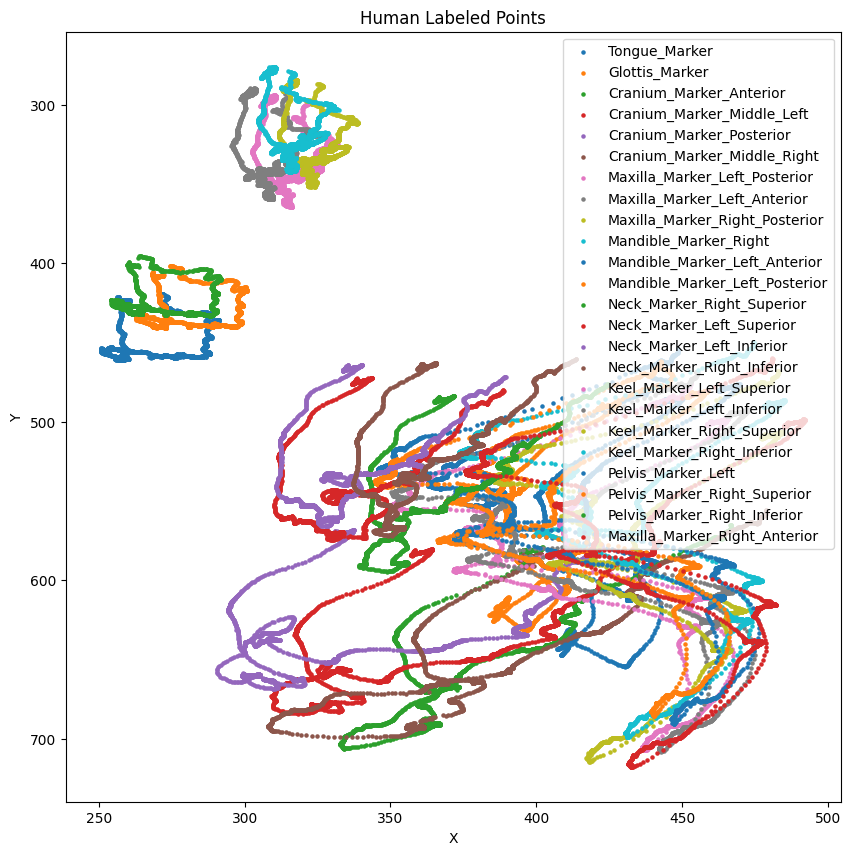

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

data_labeled_filepath = r"C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\trainingdata\CollectedData_Kelsey.csv"

# 🔥 KEY: load multi-row header properly
data_labeled = pd.read_csv(data_labeled_filepath, header=[0,1,2])

# Drop scorer level (usually redundant)
data_labeled = data_labeled[data_labeled.columns[3:]]
data_labeled.columns = data_labeled.columns.droplevel(0)

print(data_labeled.head())

plt.figure(figsize=(10,10))

bodyparts = data_labeled.columns.get_level_values(0).unique()

for bp in bodyparts:
    x = data_labeled[(bp, 'x')]
    y = data_labeled[(bp, 'y')]
    
    plt.scatter(x, y, s=5, label=bp)

plt.legend()
plt.title('Human Labeled Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.gca().invert_yaxis()
plt.show()

### Cam 2 to Cam 2

In [4]:

path_config_file_cam2 = 'e:\\Canaries\\MachineLearning\\Endive\\TestData\\Canari_cam2_training\\Canari-Kelsey-2026-02-09\\config.yaml'

folderpath_cam2 = 'e:\\Canaries\\MachineLearning\\Endive\\newdata\\Endive20250616Trial41_Cam2\\EndiveF41_20251606_Cam2_short.avi'

folderpath_all_cam2 = 'e:\\Canaries\\MachineLearning\\Endive\\newdata\\Endive20250616Trial41_Cam2'

# Change to Cam1 or Cam 2 here
config_path = path_config_file_cam2
folder_path = folderpath_cam2
folderpath_all = folderpath_all_cam2
dest_folder = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\DeepLabCut\\practice_DLC_output_cam2'

Analyzing videos with e:\Canaries\MachineLearning\Endive\TestData\Canari_cam2_training\Canari-Kelsey-2026-02-09\dlc-models-pytorch\iteration-0\CanariFeb9-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariFeb9shuffle1_snapshot_200
Starting to analyze E:\Canaries\MachineLearning\Endive\newdata\Endive20250616Trial41_Cam2\EndiveF41_20251606_Cam2_short.avi
Video metadata: 
  Overall # of frames:    2629
  Duration of video [s]:  3.51
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2629/2629 [17:15<00:00,  2.54it/s]


Saving results in C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_output_cam2\EndiveF41_20251606_Cam2_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200.h5 and C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_output_cam2\EndiveF41_20251606_Cam2_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Starting to process video: e:\Canaries\MachineLearning\Endive\newdata\Endive20250616Trial41_Cam2\EndiveF41_20251606_Cam2_short.avi
Loading e:\Canaries\MachineLearning\Endive\newdata\Endive20250616Trial41_Cam2\EndiveF41_20251606_Cam2_short.avi and data.
Duration of video [s]: 3.51, recorded with 750 fps!
Overall # of frames: 2

100%|██████████| 2629/2629 [00:28<00:00, 91.51it/s] 


Loading  e:\Canaries\MachineLearning\Endive\newdata\Endive20250616Trial41_Cam2\EndiveF41_20251606_Cam2_short.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory


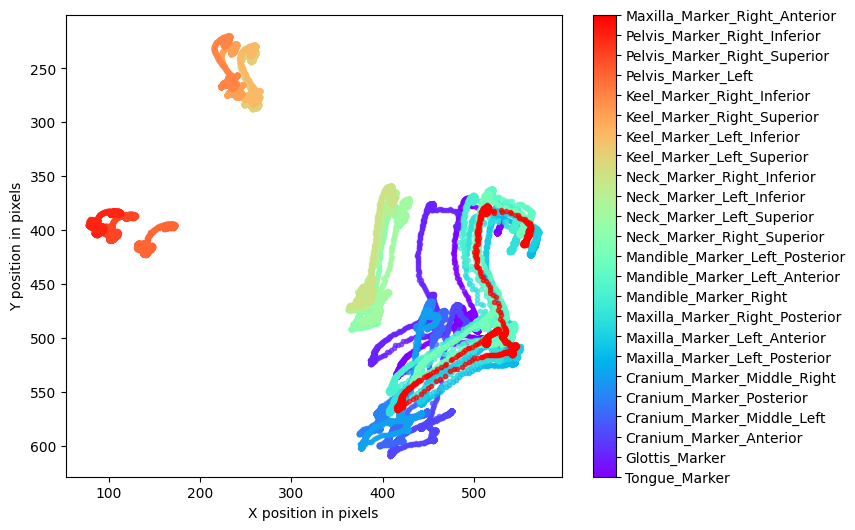

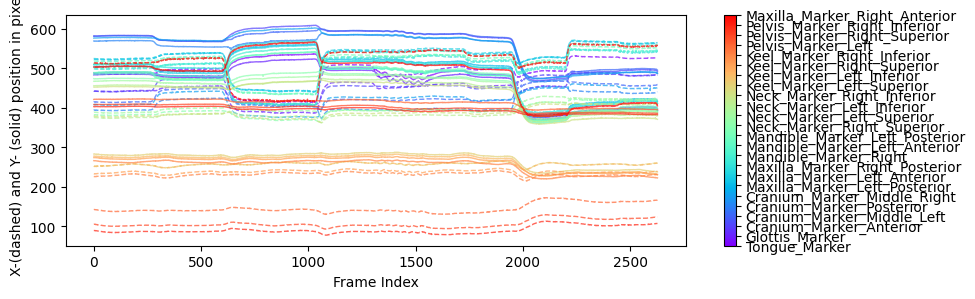

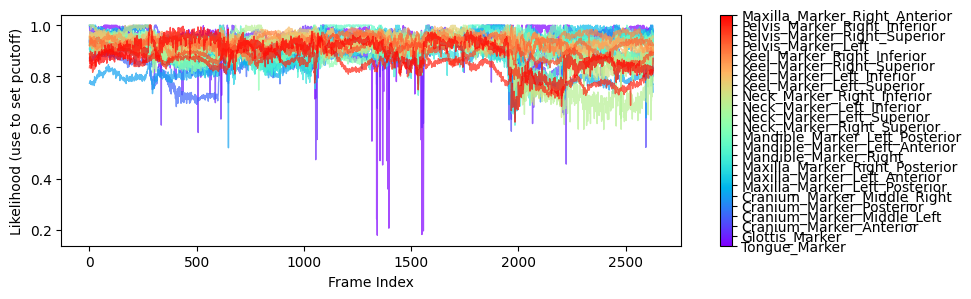

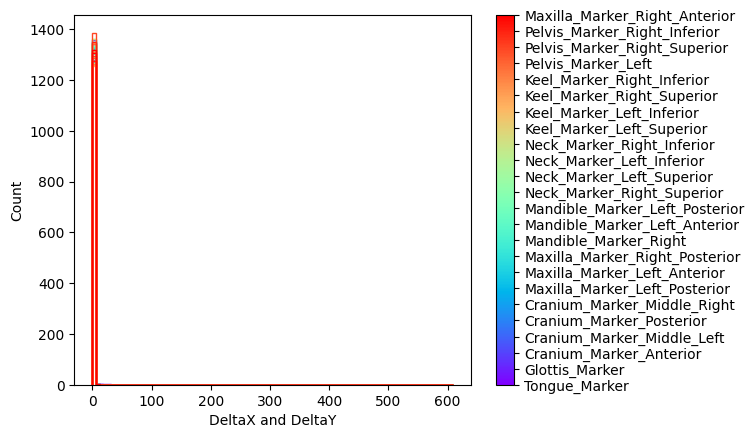

In [5]:
#Anayze New Videos (one at a time version for now)

deeplabcut.analyze_videos(config_path,
                          [folder_path],
                          destfolder=dest_folder)

deeplabcut.create_labeled_video(config_path,[folder_path],videotype = ".avi", destfolder=dest_folder)

# plot trajectories
deeplabcut.plot_trajectories(config_path,[folder_path],videotype = ".avi", destfolder=dest_folder)

# Transfer Infererence 
## Cam1 to Cam2

In [56]:
transfer_dest_folder = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\DeepLabCut\\practice_DLC_transfer_cam1cam2'

In [ ]:
#Anayze New Videos (one at a time version for now)
deeplabcut.analyze_videos(config_path,[folderpath_cam2],videotype = ".avi", destfolder=transfer_dest_folder)

deeplabcut.create_labeled_video(config_path,[folderpath_cam2],videotype = ".avi", destfolder=transfer_dest_folder)

deeplabcut.plot_trajectories(config_path,[folderpath_cam2],videotype = ".avi", destfolder=transfer_dest_folder)


Analyzing videos with e:\Canaries\MachineLearning\Endive\TestData\Canari_cam1_training\Canari-Kelsey-2026-02-09\dlc-models-pytorch\iteration-0\CanariFeb9-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariFeb9shuffle1_snapshot_200
Starting to analyze E:\Canaries\MachineLearning\Endive\newdata\Endive20250616Trial41_Cam2\EndiveF41_20251606_Cam2_short.avi
Video metadata: 
  Overall # of frames:    2629
  Duration of video [s]:  3.51
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2629/2629 [16:56<00:00,  2.59it/s]


Saving results in C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam2cam\EndiveF41_20251606_Cam2_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200.h5 and C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam2cam\EndiveF41_20251606_Cam2_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariFeb9shuffle1_snapshot_200'

In [44]:
transfer_dest_folder = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\DeepLabCut\\practice_DLC_transfer_cam2cam1'

In [ ]:
#Anayze New Videos (one at a time version for now)
deeplabcut.analyze_videos(path_config_file_cam2,[folderpath_cam1], videotype = ".avi", destfolder=transfer_dest_folder)

deeplabcut.create_labeled_video(path_config_file_cam2,[folderpath_cam1],videotype = ".avi", destfolder=transfer_dest_folder)

deeplabcut.plot_trajectories(path_config_file_cam2,[folderpath_cam1],videotype = ".avi", destfolder=transfer_dest_folder)

Analyzing videos with e:\Canaries\MachineLearning\Endive\TestData\Canari_cam2_training\Canari-Kelsey-2026-02-09\dlc-models-pytorch\iteration-0\CanariFeb9-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariFeb9shuffle1_snapshot_200
Starting to analyze E:\Canaries\MachineLearning\Endive\newdata\Endive20250616Trial41_Cam1\EndiveF41_20251606_Cam1_short.avi
Video metadata: 
  Overall # of frames:    2629
  Duration of video [s]:  3.51
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2629/2629 [16:47<00:00,  2.61it/s]


Saving results in C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam2cam1\EndiveF41_20251606_Cam1_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200.h5 and C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam2cam1\EndiveF41_20251606_Cam1_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariFeb9shuffle1_snapshot_200'

# New Bird | Same Camera

### Cam1 to Cam1

In [ ]:
path_config_file_cam1 = 'e:\\Canaries\\MachineLearning\\Endive\\TestData\\Canari_cam1_training\\Canari-Kelsey-2026-02-09\\config.yaml'

folderpath_cam1 = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\Miguel\\MiguelF6_20250816_Cam1_short.avi'

transfer_dest_folder = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\DeepLabCut\\practice_DLC_transfer_cam1Ecam1M'

In [25]:
#Anayze New Videos (one at a time version for now)
deeplabcut.analyze_videos(path_config_file_cam1,[folderpath_cam1], videotype = ".avi", destfolder=transfer_dest_folder)

Analyzing videos with e:\Canaries\MachineLearning\Endive\TestData\Canari_cam1_training\Canari-Kelsey-2026-02-09\dlc-models-pytorch\iteration-0\CanariFeb9-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariFeb9shuffle1_snapshot_200
Starting to analyze C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\Miguel\MiguelF6_20250816_Cam1_short.avi
Video metadata: 
  Overall # of frames:    980
  Duration of video [s]:  1.31
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 980/980 [06:09<00:00,  2.65it/s]


Saving results in C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam1Ecam1M\MiguelF6_20250816_Cam1_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200.h5 and C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam1Ecam1M\MiguelF6_20250816_Cam1_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariFeb9shuffle1_snapshot_200'

In [ ]:
deeplabcut.create_labeled_video(path_config_file_cam1,[folderpath_cam1], videotype = ".avi", destfolder=transfer_dest_folder, pcutoff=0.4)
deeplabcut.plot_trajectories(path_config_file_cam2,[folderpath_cam1],videotype = ".avi", destfolder=transfer_dest_folder)

Starting to process video: C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\Miguel\MiguelF6_20250816_Cam1_short.avi
Loading C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\Miguel\MiguelF6_20250816_Cam1_short.avi and data.
Duration of video [s]: 1.31, recorded with 750 fps!
Overall # of frames: 980 with cropped frame dimensions: 768 768
Generating frames and creating video.


100%|██████████| 980/980 [00:09<00:00, 105.41it/s]


[True]

### Cam2 to Cam2


In [29]:
path_config_file_cam2 = 'e:\\Canaries\\MachineLearning\\Endive\\TestData\\Canari_cam2_training\\Canari-Kelsey-2026-02-09\\config.yaml'
folderpath_cam2 = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\Miguel\\MiguelF6_20250816_Cam2_short.avi'
transfer_dest_folder = 'C:\\Users\\kstilson\\TylerWorking\\BirdSongs-MNHN\\Testing\\DeepLabCut\\practice_DLC_transfer_cam2Ecam2M'

In [30]:
#Anayze New Videos (one at a time version for now)
deeplabcut.analyze_videos(path_config_file_cam1,[folderpath_cam1], videotype = ".avi", destfolder=transfer_dest_folder)

Analyzing videos with e:\Canaries\MachineLearning\Endive\TestData\Canari_cam1_training\Canari-Kelsey-2026-02-09\dlc-models-pytorch\iteration-0\CanariFeb9-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariFeb9shuffle1_snapshot_200
Starting to analyze C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\Miguel\MiguelF6_20250816_Cam1_short.avi
Video metadata: 
  Overall # of frames:    980
  Duration of video [s]:  1.31
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 980/980 [06:21<00:00,  2.57it/s]


Saving results in C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam2Ecam2M\MiguelF6_20250816_Cam1_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200.h5 and C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\DeepLabCut\practice_DLC_transfer_cam2Ecam2M\MiguelF6_20250816_Cam1_shortDLC_Resnet50_CanariFeb9shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariFeb9shuffle1_snapshot_200'

Starting to process video: C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\Miguel\MiguelF6_20250816_Cam1_short.avi
Loading C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\Miguel\MiguelF6_20250816_Cam1_short.avi and data.
Duration of video [s]: 1.31, recorded with 750 fps!
Overall # of frames: 980 with cropped frame dimensions: 768 768
Generating frames and creating video.


100%|██████████| 980/980 [00:08<00:00, 112.48it/s]


Loading  C:\Users\kstilson\TylerWorking\BirdSongs-MNHN\Testing\Miguel\MiguelF6_20250816_Cam1_short.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory


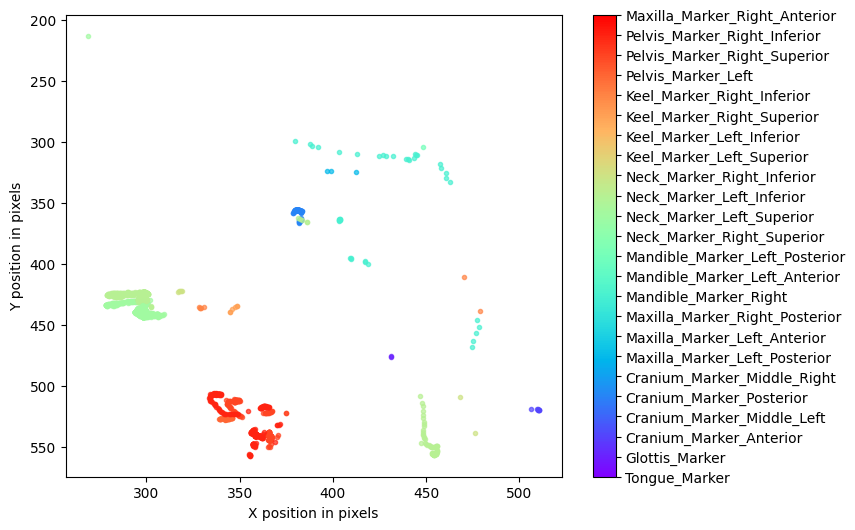

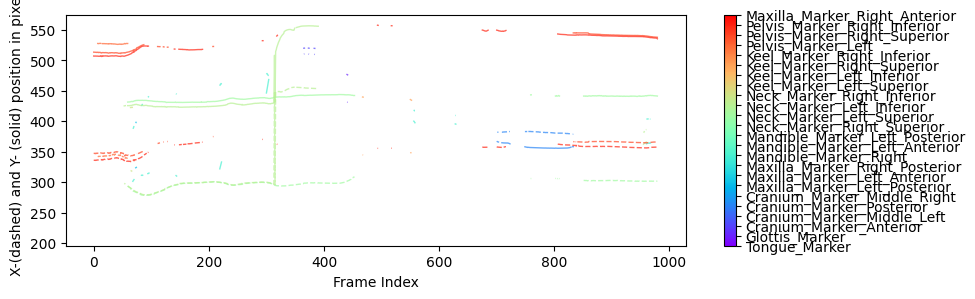

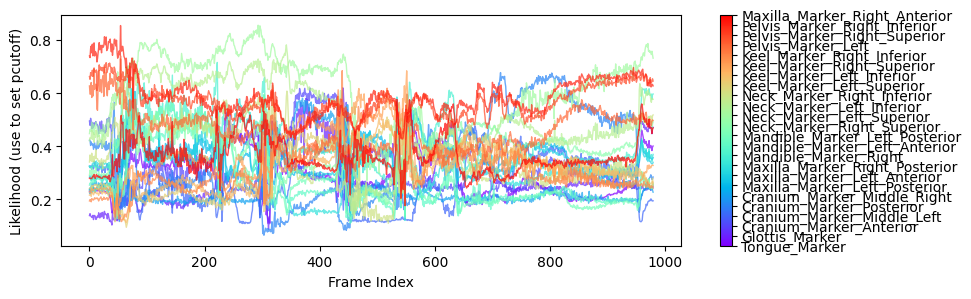

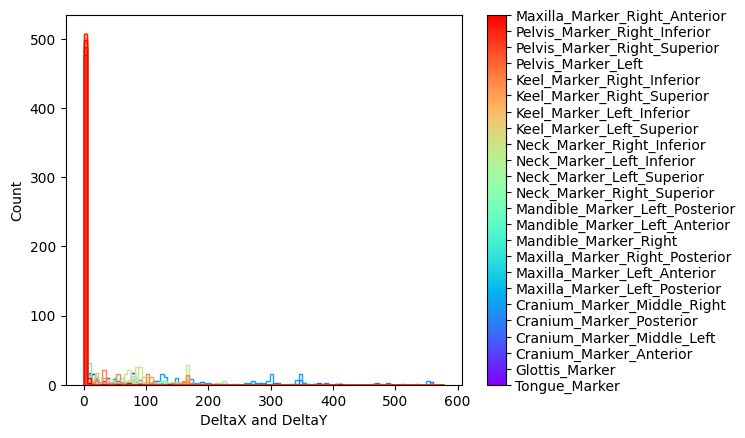

In [32]:
deeplabcut.create_labeled_video(path_config_file_cam1,[folderpath_cam1], videotype = ".avi", destfolder=transfer_dest_folder, pcutoff=0.4)
deeplabcut.plot_trajectories(path_config_file_cam2,[folderpath_cam1],videotype = ".avi", destfolder=transfer_dest_folder)